# Notebook 03 – Strong Classical Baselines trước Deep Learning

Notebook này cố ý giữ toàn bộ đầu vào ở dạng sparse. Nó so sánh:

- Logistic Regression One-vs-Rest.
- LinearSVC One-vs-Rest.
- Có/không `class_weight='balanced'`.
- Threshold theo nhóm support, sau đó shrink threshold riêng của nhãn về threshold nhóm.

Model được chọn hoàn toàn bằng validation; test chỉ dùng ở bước cuối.


In [1]:
import json
import pickle
import random
import re
import time
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.sparse import hstack, load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    label_ranking_average_precision_score,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path('..').resolve()
DATA_OUT = PROJECT_ROOT / 'Dataset' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load sparse features


In [2]:
X_train = load_npz(DATA_OUT / 'X_train.npz')
X_val = load_npz(DATA_OUT / 'X_val.npz')
X_test = load_npz(DATA_OUT / 'X_test.npz')
Y_train = np.load(DATA_OUT / 'Y_train.npy')
Y_val = np.load(DATA_OUT / 'Y_val.npy')
Y_test = np.load(DATA_OUT / 'Y_test.npy')

with open(DATA_OUT / 'label_vocab.json', encoding='utf-8') as f:
    label_vocab = json.load(f)
ALL_LABELS = label_vocab['labels']

print('X train:', X_train.shape, X_train.dtype)
print('Y train:', Y_train.shape)
print('Labels :', len(ALL_LABELS), '(parent-level)')
assert X_train.shape[0] == Y_train.shape[0]
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]


X train: (9802, 140000) float32
Y train: (9802, 133)
Labels : 133 (parent-level)


## 2. Metrics phù hợp dữ liệu multi-label thưa


In [3]:
def precision_at_k(y_true, y_score, k):
    top = np.argpartition(-y_score, kth=min(k, y_score.shape[1]) - 1, axis=1)[:, :k]
    return float(np.mean([y_true[i, top[i]].sum() / k for i in range(len(y_true))]))


def recall_at_k(y_true, y_score, k):
    top = np.argpartition(-y_score, kth=min(k, y_score.shape[1]) - 1, axis=1)[:, :k]
    values = []
    for i in range(len(y_true)):
        positives = y_true[i].sum()
        if positives:
            values.append(y_true[i, top[i]].sum() / positives)
    return float(np.mean(values))


def evaluate_multilabel(y_true, y_score, thresholds, model_name):
    thresholds = np.asarray(thresholds)
    y_pred = (y_score >= thresholds[None, :]).astype(np.int8)
    return {
        'Model': model_name,
        'Micro F1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Samples F1': f1_score(y_true, y_pred, average='samples', zero_division=0),
        'Hamming Loss': hamming_loss(y_true, y_pred),
        'LRAP': label_ranking_average_precision_score(y_true, y_score),
        'Precision@1': precision_at_k(y_true, y_score, 1),
        'Precision@3': precision_at_k(y_true, y_score, 3),
        'Recall@3': recall_at_k(y_true, y_score, 3),
        'Pred labels/sample': float(y_pred.sum(axis=1).mean()),
    }


all_zero_hamming = float(Y_val.mean())
print('All-zero Hamming baseline:', round(all_zero_hamming, 6))
print('True labels/sample        :', round(float(Y_val.sum(axis=1).mean()), 3))


All-zero Hamming baseline: 0.008037
True labels/sample        : 1.069


## 3. Support-aware threshold tuning trên validation


In [4]:
def candidate_thresholds(scores, n=70):
    '''Quantile phù hợp cho output thưa; thêm 0 và 0.5 cho probability model.'''
    quantiles = np.linspace(0.90, 0.9995, n)
    values = np.quantile(scores, quantiles)
    return np.unique(np.r_[values, 0.0, 0.5])


def best_binary_threshold(y_true, scores, candidates):
    best_t, best_f1 = candidates[0], -1.0
    for threshold in candidates:
        score = f1_score(y_true, scores >= threshold, zero_division=0)
        if score > best_f1:
            best_t, best_f1 = float(threshold), float(score)
    return best_t, best_f1


def tune_support_aware_thresholds(y_val, val_scores, train_support):
    '''
    1) Tune threshold chung theo 3 bucket support.
    2) Với nhãn đủ positive ở validation, tune riêng rồi shrink về bucket threshold.
    '''
    buckets = {
        'rare': train_support < 30,
        'medium': (train_support >= 30) & (train_support < 100),
        'frequent': train_support >= 100,
    }
    thresholds = np.zeros(y_val.shape[1], dtype=np.float64)
    bucket_values = {}

    for name, mask in buckets.items():
        if not mask.any():
            continue
        candidates = candidate_thresholds(val_scores[:, mask])
        best_t, best_score = candidates[0], -1.0
        for threshold in candidates:
            score = f1_score(
                y_val[:, mask], val_scores[:, mask] >= threshold,
                average='micro', zero_division=0
            )
            if score > best_score:
                best_t, best_score = float(threshold), float(score)
        thresholds[mask] = best_t
        bucket_values[name] = {'threshold': best_t, 'micro_f1': best_score}

    # Per-label threshold chỉ dùng khi validation có đủ positive; shrink chống overfit.
    val_support = y_val.sum(axis=0)
    for label_idx in range(y_val.shape[1]):
        if val_support[label_idx] < 5:
            continue
        anchor = thresholds[label_idx]
        candidates = np.unique(np.r_[candidate_thresholds(val_scores[:, label_idx]), anchor])
        label_t, _ = best_binary_threshold(
            y_val[:, label_idx], val_scores[:, label_idx], candidates
        )
        reliability = float(val_support[label_idx] / (val_support[label_idx] + 20.0))
        thresholds[label_idx] = reliability * label_t + (1.0 - reliability) * anchor

    return thresholds, bucket_values


## 4. So sánh LR/SVC và chiến lược class balancing


In [5]:
MODEL_CONFIGS = {
    'LR': OneVsRestClassifier(
        LogisticRegression(
            C=1.0, solver='liblinear', max_iter=1000,
            class_weight=None, random_state=SEED
        ),
        n_jobs=-1,
    ),
    'LR_balanced': OneVsRestClassifier(
        LogisticRegression(
            C=1.0, solver='liblinear', max_iter=1000,
            class_weight='balanced', random_state=SEED
        ),
        n_jobs=-1,
    ),
    'LinearSVC': OneVsRestClassifier(
        LinearSVC(
            C=0.3, class_weight=None, max_iter=5000,
            dual=True, random_state=SEED
        ),
        n_jobs=-1,
    ),
    'LinearSVC_balanced': OneVsRestClassifier(
        LinearSVC(
            C=0.3, class_weight='balanced', max_iter=5000,
            dual=True, random_state=SEED
        ),
        n_jobs=-1,
    ),
}


def model_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return np.asarray(model.predict_proba(X), dtype=np.float64)
    return np.asarray(model.decision_function(X), dtype=np.float64)


trained_models = {}
thresholds_by_model = {}
validation_rows = []
train_support = Y_train.sum(axis=0)

for model_name, estimator in MODEL_CONFIGS.items():
    print(f'\nTraining {model_name} ...')
    started = time.time()
    estimator.fit(X_train, Y_train)
    elapsed = time.time() - started

    val_scores = model_scores(estimator, X_val)
    thresholds, bucket_info = tune_support_aware_thresholds(
        Y_val, val_scores, train_support
    )
    metrics = evaluate_multilabel(Y_val, val_scores, thresholds, model_name)
    metrics['Train seconds'] = elapsed
    # Cân bằng khả năng hard classification và ranking phục vụ Top-K.
    metrics['Selection score'] = (
        0.45 * metrics['Micro F1']
        + 0.35 * metrics['Macro F1']
        + 0.20 * metrics['LRAP']
    )

    trained_models[model_name] = estimator
    thresholds_by_model[model_name] = thresholds
    validation_rows.append(metrics)
    print(pd.Series(metrics).drop('Model').astype(float).round(4).to_string())
    print('Bucket thresholds:', bucket_info)

validation_df = pd.DataFrame(validation_rows).sort_values(
    'Selection score', ascending=False
).reset_index(drop=True)
display(validation_df.round(4))

BEST_MODEL_NAME = validation_df.loc[0, 'Model']
best_model = trained_models[BEST_MODEL_NAME]
best_thresholds = thresholds_by_model[BEST_MODEL_NAME]
print('\nSelected on validation:', BEST_MODEL_NAME)



Training LR ...


Micro F1               0.4579
Macro F1               0.3111
Samples F1             0.3912
Hamming Loss           0.0084
LRAP                   0.5140
Precision@1            0.4122
Precision@3            0.2022
Recall@3               0.5628
Pred labels/sample     0.9882
Train seconds         98.3951
Selection score        0.4177
Bucket thresholds: {'rare': {'threshold': 0.006747074226209044, 'micro_f1': 0.22797927461139897}, 'medium': {'threshold': 0.037059793560136514, 'micro_f1': 0.4260355029585799}, 'frequent': {'threshold': 0.13767765606719373, 'micro_f1': 0.49502487562189057}}

Training LR_balanced ...
Micro F1                0.5024
Macro F1                0.3928
Samples F1              0.4391
Hamming Loss            0.0079
LRAP                    0.6200
Precision@1             0.5063
Precision@3             0.2474
Recall@3                0.6940
Pred labels/sample      1.0400
Train seconds         137.0269
Selection score         0.4876
Bucket thresholds: {'rare': {'threshold': 0.3

,Model,Micro F1,Macro F1,Samples F1,Hamming Loss,LRAP,Precision@1,Precision@3,Recall@3,Pred labels/sample,Train seconds,Selection score
0,LinearSVC_balanced,0.5165,0.4064,0.4477,0.0074,0.6227,0.5078,0.2516,0.7053,0.9765,40.5622,0.4992
1,LinearSVC,0.5202,0.3926,0.4488,0.0073,0.6099,0.5008,0.2427,0.6803,0.9498,34.4908,0.4935
2,LR_balanced,0.5024,0.3928,0.4391,0.0079,0.6200,0.5063,0.2474,0.6940,1.0400,137.0269,0.4876
3,LR,0.4579,0.3111,0.3912,0.0084,0.5140,0.4122,0.2022,0.5628,0.9882,98.3951,0.4177



Selected on validation: LinearSVC_balanced


## 5. Đánh giá duy nhất model đã chọn trên test


In [9]:
test_scores = model_scores(best_model, X_test)
test_metrics = evaluate_multilabel(
    Y_test, test_scores, best_thresholds, f'{BEST_MODEL_NAME} [TEST]'
)
test_df = pd.DataFrame([test_metrics])

print(test_df.T.to_string(header=False))
validation_df.to_csv(RESULTS_DIR / 'baseline_validation_comparison.csv', index=False)
test_df.to_csv(RESULTS_DIR / 'baseline_test_metrics.csv', index=False)

test_pred = (test_scores >= best_thresholds[None, :]).astype(np.int8)
per_label = pd.DataFrame({
    'Label': ALL_LABELS,
    'Train support': Y_train.sum(axis=0),
    'Val support': Y_val.sum(axis=0),
    'Test support': Y_test.sum(axis=0),
    'Threshold': best_thresholds,
    'Test F1': f1_score(Y_test, test_pred, average=None, zero_division=0),
}).sort_values(['Test F1', 'Test support'])
per_label.to_csv(RESULTS_DIR / 'per_label_f1_baseline.csv', index=False)

print('\nLabels có Test F1 = 0:', int((per_label['Test F1'] == 0).sum()))
display(per_label.head(20))


Model               LinearSVC_balanced [TEST]
Micro F1                             0.521329
Macro F1                             0.396866
Samples F1                           0.449924
Hamming Loss                          0.00723
LRAP                                 0.628035
Precision@1                          0.524711
Precision@3                          0.247809
Recall@3                             0.695408
Pred labels/sample                   0.935331

Labels có Test F1 = 0: 26


,Label,Train support,Val support,Test support,Threshold,Test F1
3,T0846,11,2,2,-0.410916,0.0
15,T1037,10,2,2,-0.410916,0.0
40,T1112,10,2,2,-0.410916,0.0
47,T1129,10,2,2,-0.410916,0.0
72,T1420,10,2,2,-0.410916,0.0
86,T1525,10,2,2,-0.410916,0.0
87,T1528,11,2,2,-0.410916,0.0
108,T1569,10,2,2,-0.410916,0.0
61,T1205,16,2,3,-0.410916,0.0
77,T1485,15,2,3,-0.410916,0.0


## 6. Lưu model và threshold


In [10]:
with open(MODELS_DIR / 'best_baseline_ovr.pkl', 'wb') as f:
    pickle.dump(best_model, f)

threshold_payload = {
    'model_name': BEST_MODEL_NAME,
    'label_mode': 'parent',
    'labels': ALL_LABELS,
    'thresholds': best_thresholds.tolist(),
    'selection_metric': '0.45*micro_f1 + 0.35*macro_f1 + 0.20*lrap',
}
with open(MODELS_DIR / 'baseline_thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(threshold_payload, f, indent=2, ensure_ascii=False)

print('Saved best_baseline_ovr.pkl and baseline_thresholds.json')


Saved best_baseline_ovr.pkl and baseline_thresholds.json


## 7. Inference dùng đúng preprocessing và vectorizer của training


In [12]:
with open(MODELS_DIR / 'word_tfidf_vectorizer.pkl', 'rb') as f:
    word_tfidf = pickle.load(f)
with open(MODELS_DIR / 'char_tfidf_vectorizer.pkl', 'rb') as f:
    char_tfidf = pickle.load(f)
with open(MODELS_DIR / 'feature_config.json', encoding='utf-8') as f:
    feature_config = json.load(f)

NER_PATTERNS = [
    (r'\bCVE-\d{4}-\d{4,7}\b', ' ioc_cve '),
    (r'\b(?:\d{1,3}\.){3}\d{1,3}(?:/\d{1,2})?\b', ' ioc_ip '),
    (r'\b(?:[0-9a-f]{1,4}:){3,7}[0-9a-f]{1,4}\b', ' ioc_ip '),
    (r'\b[0-9a-f]{32}\b|\b[0-9a-f]{40}\b|\b[0-9a-f]{64}\b', ' ioc_hash '),
    (r'https?://[^\s"\']+', ' ioc_url '),
    (r'\b[\w.+-]+@[\w-]+\.[a-z]{2,}\b', ' ioc_email '),
    (r'[a-z]:\\(?:[^\\\s]+\\)*[^\\\s]+', ' ioc_path '),
    (r'(?<!\w)/(?:etc|home|var|usr|tmp|bin|sbin|opt|proc|dev|sys)(?:/[^\s,;]+)+', ' ioc_path '),
    (r'\bports?\s*(?:number\s*)?\d{1,5}\b|:\d{2,5}\b', ' ioc_port '),
]


def mask_entities(text):
    text = str(text)
    for pattern, replacement in NER_PATTERNS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text


def clean_text(text):
    text = unicodedata.normalize('NFKC', str(text)).lower()
    text = mask_entities(text)
    text = re.sub(r'[^a-z0-9_\-./\\:\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def transform_texts(raw_texts):
    cleaned = [clean_text(x) for x in raw_texts]
    X_word = word_tfidf.transform(cleaned)
    X_char = char_tfidf.transform(cleaned)
    return hstack(
        [X_word, X_char.multiply(feature_config['char_weight'])],
        format='csr'
    ).astype(np.float32)


def predict_confident_labels(raw_text):
    """Trả về mọi parent technique có score vượt threshold riêng của nhãn."""
    X = transform_texts([raw_text])
    scores = model_scores(best_model, X)[0]
    confident_indices = np.flatnonzero(scores >= best_thresholds)

    # Xếp các nhãn đạt ngưỡng theo margin = score - threshold.
    margins = scores[confident_indices] - best_thresholds[confident_indices]
    order = confident_indices[np.argsort(margins)[::-1]]
    return [ALL_LABELS[idx] for idx in order]


probe = clean_text('CVE-2021-44228 contacted 10.0.0.1:443 without authentication')
assert 'ioc_cve' in probe and 'ioc_ip' in probe and 'without' in probe

sample_text = (
    'The attacker used PowerShell and WMI for remote execution, then dumped '
    'credentials from LSASS with Mimikatz and contacted 10.0.0.1:443.'
)
print('Confident parent techniques:', predict_confident_labels(sample_text))


Confident parent techniques: ['T1003', 'T1047']


## Bước tiếp theo

Chỉ chuyển sang deep learning sau khi:

- Chạy ablation Word-only so với Word+Char.
- Baseline ổn định qua nhiều seed hoặc cross-validation.
- Kiểm thử trên một tập CTI thực, không trùng template với dữ liệu huấn luyện.
- Báo cáo riêng parent-level F1 và exact sub-technique F1; không so trực tiếp hai label space.


In [13]:
# ===== TEST DỰ ĐOÁN VỚI CTI TEXT MỚI =====
# Thay nội dung custom_text bằng báo cáo CTI bạn muốn kiểm thử.
custom_text = """
The attacker used PowerShell to execute an encoded malicious script.
WMI was leveraged for remote execution and lateral movement.
Mimikatz accessed LSASS and extracted NTLM credential hashes.
The compromised host contacted 10.0.0.1:443 for command and control.
"""

predicted_labels = predict_confident_labels(custom_text)

print('Predicted labels:', predicted_labels)
if not predicted_labels:
    print('Không có nhãn nào vượt threshold.')


Predicted labels: ['T1003', 'T1047', 'T1021']


In [14]:
tp = ((test_pred == 1) & (Y_test == 1)).sum(axis=0)
fp = ((test_pred == 1) & (Y_test == 0)).sum(axis=0)
fn = ((test_pred == 0) & (Y_test == 1)).sum(axis=0)

zero_label_audit = pd.DataFrame({
    "Label": ALL_LABELS,
    "Train support": Y_train.sum(axis=0),
    "Val support": Y_val.sum(axis=0),
    "Test support": Y_test.sum(axis=0),
    "Predicted positives": test_pred.sum(axis=0),
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "Threshold": best_thresholds,
    "Test F1": f1_score(
        Y_test, test_pred, average=None, zero_division=0
    ),
})

zero_label_audit = zero_label_audit[
    zero_label_audit["Test F1"] == 0
].sort_values(["Train support", "Test support"])

display(zero_label_audit)
zero_label_audit.to_csv(
    RESULTS_DIR / "zero_f1_label_audit.csv",
    index=False
)

,Label,Train support,Val support,Test support,Predicted positives,TP,FP,FN,Threshold,Test F1
15,T1037,10,2,2,2,0,2,2,-0.410916,0.0
40,T1112,10,2,2,0,0,0,2,-0.410916,0.0
47,T1129,10,2,2,0,0,0,2,-0.410916,0.0
72,T1420,10,2,2,0,0,0,2,-0.410916,0.0
86,T1525,10,2,2,0,0,0,2,-0.410916,0.0
108,T1569,10,2,2,1,0,1,2,-0.410916,0.0
3,T0846,11,2,2,0,0,0,2,-0.410916,0.0
87,T1528,11,2,2,0,0,0,2,-0.410916,0.0
79,T1491,14,2,3,1,0,1,3,-0.410916,0.0
77,T1485,15,2,3,0,0,0,3,-0.410916,0.0


## 5.1. Extended metrics và trực quan hóa kết quả

Các metric bổ sung giúp tách chất lượng hard classification, ranking và độ phủ nhãn.


In [15]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    coverage_error,
    fbeta_score,
    jaccard_score,
    label_ranking_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Precision / Recall / F1 / Jaccard ở ba cách averaging.
classification_rows = []
for average in ['micro', 'macro', 'samples']:
    classification_rows.append({
        'Average': average,
        'Precision': precision_score(
            Y_test, test_pred, average=average, zero_division=0
        ),
        'Recall': recall_score(
            Y_test, test_pred, average=average, zero_division=0
        ),
        'F1': f1_score(
            Y_test, test_pred, average=average, zero_division=0
        ),
        'F2 (ưu tiên Recall)': fbeta_score(
            Y_test, test_pred, beta=2, average=average, zero_division=0
        ),
        'Jaccard': jaccard_score(
            Y_test, test_pred, average=average, zero_division=0
        ),
    })

classification_metrics_df = pd.DataFrame(classification_rows)

# Ranking metrics dùng decision score, không yêu cầu probability calibration.
extended_test_metrics = {
    'Subset Accuracy (Exact Match)': accuracy_score(Y_test, test_pred),
    'Hamming Loss': hamming_loss(Y_test, test_pred),
    'LRAP': label_ranking_average_precision_score(Y_test, test_scores),
    'Average Precision Micro': average_precision_score(
        Y_test, test_scores, average='micro'
    ),
    'Average Precision Macro': average_precision_score(
        Y_test, test_scores, average='macro'
    ),
    'ROC-AUC Micro': roc_auc_score(Y_test, test_scores, average='micro'),
    'ROC-AUC Macro': roc_auc_score(Y_test, test_scores, average='macro'),
    'Coverage Error': coverage_error(Y_test, test_scores),
    'Label Ranking Loss': label_ranking_loss(Y_test, test_scores),
    'MCC Micro (flattened)': matthews_corrcoef(
        Y_test.ravel(), test_pred.ravel()
    ),
    'True labels/sample': float(Y_test.sum(axis=1).mean()),
    'Predicted labels/sample': float(test_pred.sum(axis=1).mean()),
    'No-label prediction rate': float((test_pred.sum(axis=1) == 0).mean()),
    'Exact-match sample count': int(
        np.all(Y_test == test_pred, axis=1).sum()
    ),
}
extended_test_metrics_df = pd.DataFrame(
    list(extended_test_metrics.items()), columns=['Metric', 'Value']
)

print('=== Classification metrics ===')
display(classification_metrics_df.round(4))
print('\n=== Ranking and global metrics ===')
display(extended_test_metrics_df.round(4))

classification_metrics_df.to_csv(
    RESULTS_DIR / 'classification_metrics_by_average.csv', index=False
)
extended_test_metrics_df.to_csv(
    RESULTS_DIR / 'extended_test_metrics.csv', index=False
)

=== Classification metrics ===


,Average,Precision,Recall,F1,F2 (ưu tiên Recall),Jaccard
0,micro,0.5599,0.4878,0.5213,0.5007,0.3526
1,macro,0.4420,0.3950,0.3969,0.3916,0.2821
2,samples,0.4363,0.4902,0.4499,0.4690,0.4232



=== Ranking and global metrics ===


,Metric,Value
0,Subset Accuracy (Exact Match),0.3465
1,Hamming Loss,0.0072
2,LRAP,0.6280
3,Average Precision Micro,0.5192
4,Average Precision Macro,0.4368
5,ROC-AUC Micro,0.9487
6,ROC-AUC Macro,0.9247
7,Coverage Error,8.8580
8,Label Ranking Loss,0.0563
9,MCC Micro (flattened),0.5190


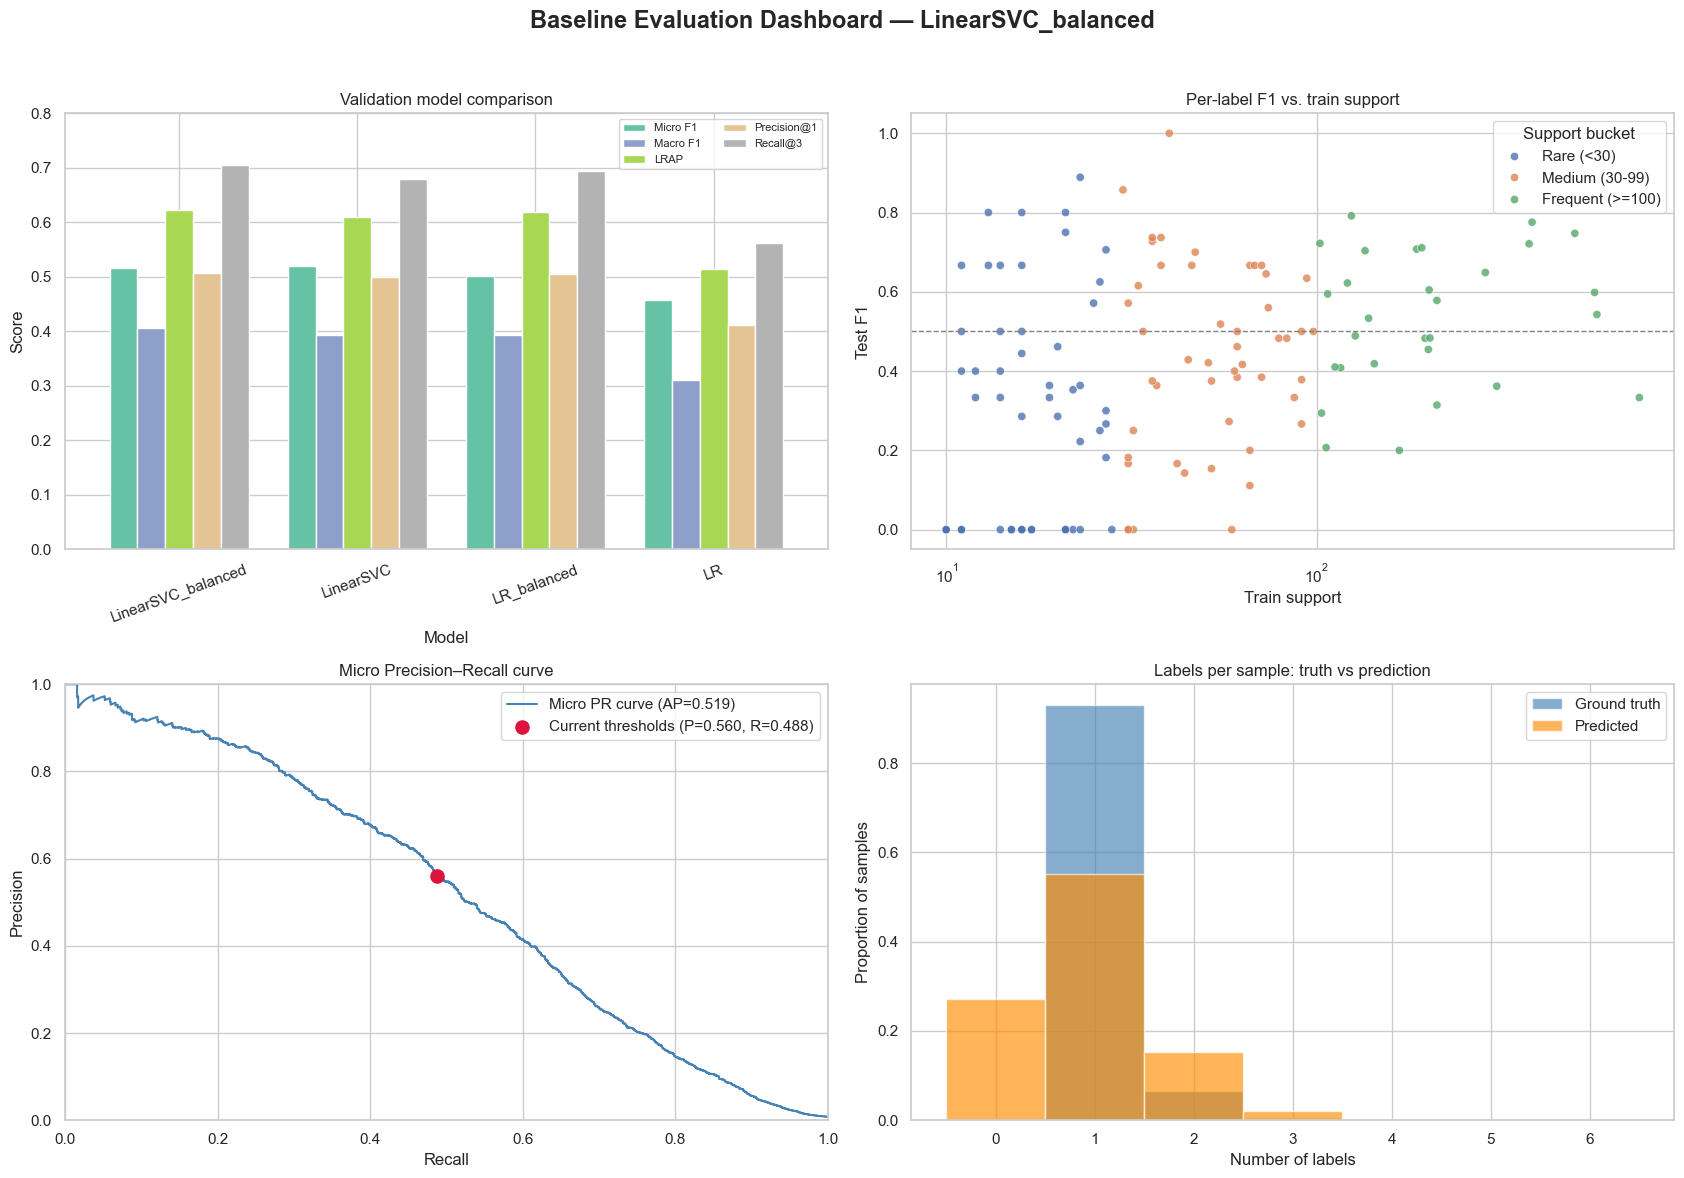

In [16]:
import seaborn as sns
from sklearn.metrics import precision_recall_curve

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# (1) So sánh model trên validation. Không dùng test để chọn model.
comparison_metrics = [
    'Micro F1', 'Macro F1', 'LRAP', 'Precision@1', 'Recall@3'
]
validation_plot = validation_df.set_index('Model')[comparison_metrics]
validation_plot.plot(
    kind='bar', ax=axes[0, 0], width=0.78, colormap='Set2'
)
axes[0, 0].set_title('Validation model comparison')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 0.8)
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(fontsize=8, ncol=2)

# (2) Train support so với Test F1 từng label.
support_values = per_label['Train support'].to_numpy()
f1_values = per_label['Test F1'].to_numpy()
support_bucket = pd.cut(
    support_values,
    bins=[0, 29, 99, np.inf],
    labels=['Rare (<30)', 'Medium (30-99)', 'Frequent (>=100)']
)
scatter_df = pd.DataFrame({
    'Train support': support_values,
    'Test F1': f1_values,
    'Support bucket': support_bucket,
})
sns.scatterplot(
    data=scatter_df, x='Train support', y='Test F1',
    hue='Support bucket', alpha=0.8, ax=axes[0, 1]
)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Per-label F1 vs. train support')
axes[0, 1].axhline(0.5, color='gray', linestyle='--', linewidth=1)

# (3) Micro Precision–Recall curve và operating point hiện tại.
pr_precision, pr_recall, _ = precision_recall_curve(
    Y_test.ravel(), test_scores.ravel()
)
current_micro_precision = precision_score(
    Y_test, test_pred, average='micro', zero_division=0
)
current_micro_recall = recall_score(
    Y_test, test_pred, average='micro', zero_division=0
)
micro_ap = average_precision_score(Y_test, test_scores, average='micro')
axes[1, 0].plot(
    pr_recall, pr_precision, color='steelblue',
    label=f'Micro PR curve (AP={micro_ap:.3f})'
)
axes[1, 0].scatter(
    [current_micro_recall], [current_micro_precision],
    color='crimson', s=90, zorder=5,
    label=(f'Current thresholds '
           f'(P={current_micro_precision:.3f}, R={current_micro_recall:.3f})')
)
axes[1, 0].set_title('Micro Precision–Recall curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

# (4) Số nhãn thật và dự đoán trên mỗi sample.
true_cardinality = Y_test.sum(axis=1)
pred_cardinality = test_pred.sum(axis=1)
max_cardinality = int(max(true_cardinality.max(), pred_cardinality.max(), 4))
bins = np.arange(-0.5, max_cardinality + 1.5, 1)
axes[1, 1].hist(
    true_cardinality, bins=bins, alpha=0.65,
    label='Ground truth', color='steelblue', density=True
)
axes[1, 1].hist(
    pred_cardinality, bins=bins, alpha=0.65,
    label='Predicted', color='darkorange', density=True
)
axes[1, 1].set_title('Labels per sample: truth vs prediction')
axes[1, 1].set_xlabel('Number of labels')
axes[1, 1].set_ylabel('Proportion of samples')
axes[1, 1].legend()

plt.suptitle(
    f'Baseline Evaluation Dashboard — {BEST_MODEL_NAME}',
    fontsize=17, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    RESULTS_DIR / 'baseline_evaluation_dashboard.png',
    dpi=180, bbox_inches='tight'
)
plt.show()

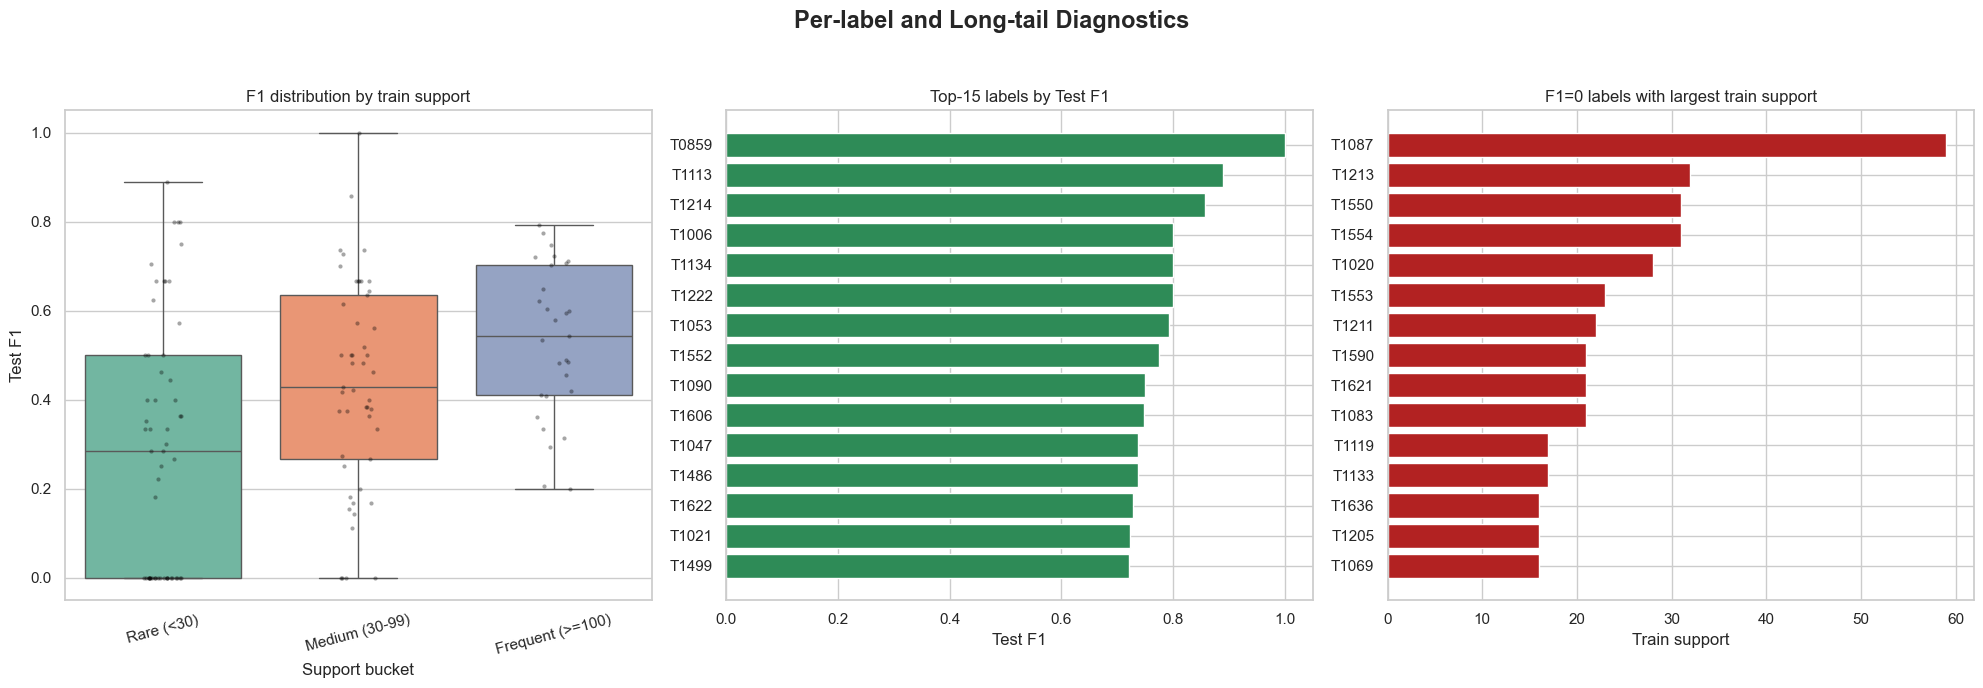

,Support bucket,Labels,Mean_F1,Median_F1,Zero_F1,Mean_train_support
0,Rare (<30),55,0.2925,0.2857,22,17.4364
1,Medium (30-99),49,0.4334,0.4286,4,55.1633
2,Frequent (>=100),29,0.5331,0.5427,0,238.5172


In [17]:
# Dashboard chẩn đoán long-tail và label-level performance.
per_label_plot = per_label.copy()
per_label_plot['Support bucket'] = pd.cut(
    per_label_plot['Train support'],
    bins=[0, 29, 99, np.inf],
    labels=['Rare (<30)', 'Medium (30-99)', 'Frequent (>=100)']
)

top_labels = per_label_plot.nlargest(15, 'Test F1').sort_values('Test F1')
worst_supported = (
    per_label_plot[per_label_plot['Test F1'] == 0]
    .nlargest(15, 'Train support')
    .sort_values('Train support')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

sns.boxplot(
    data=per_label_plot,
    x='Support bucket', y='Test F1',
    order=['Rare (<30)', 'Medium (30-99)', 'Frequent (>=100)'],
    ax=axes[0], palette='Set2'
)
sns.stripplot(
    data=per_label_plot,
    x='Support bucket', y='Test F1',
    order=['Rare (<30)', 'Medium (30-99)', 'Frequent (>=100)'],
    color='black', alpha=0.35, size=3, ax=axes[0]
)
axes[0].set_title('F1 distribution by train support')
axes[0].tick_params(axis='x', rotation=15)

axes[1].barh(top_labels['Label'], top_labels['Test F1'], color='seagreen')
axes[1].set_title('Top-15 labels by Test F1')
axes[1].set_xlabel('Test F1')
axes[1].set_xlim(0, 1.05)

if len(worst_supported):
    axes[2].barh(
        worst_supported['Label'], worst_supported['Train support'],
        color='firebrick'
    )
    axes[2].set_title('F1=0 labels with largest train support')
    axes[2].set_xlabel('Train support')
else:
    axes[2].text(0.5, 0.5, 'No labels with F1=0', ha='center', va='center')
    axes[2].set_axis_off()

plt.suptitle('Per-label and Long-tail Diagnostics', fontsize=17, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    RESULTS_DIR / 'per_label_diagnostics.png',
    dpi=180, bbox_inches='tight'
)
plt.show()

bucket_summary = (
    per_label_plot.groupby('Support bucket', observed=True)
    .agg(
        Labels=('Label', 'count'),
        Mean_F1=('Test F1', 'mean'),
        Median_F1=('Test F1', 'median'),
        Zero_F1=('Test F1', lambda x: int((x == 0).sum())),
        Mean_train_support=('Train support', 'mean'),
    )
    .reset_index()
)
display(bucket_summary.round(4))
bucket_summary.to_csv(
    RESULTS_DIR / 'support_bucket_performance.csv', index=False
)